# 1). Import Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from category_encoders import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split

# 2). Load dataset

In [2]:
df=pd.read_csv("/workspaces/Modelling_Credit_Defaults-Logistic_Regression-/data/lending_club_loan_data/clean_data.csv")
df.head()

,loan_amnt,term,int_rate,installment,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,...,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies
0,5000,36 months,10.65,162.87,NaN,10+ years,RENT,24000.0,Verified,0,...,27.65,0,1985-01-01,1,3,0,13648,83.7,9,0.0
1,2500,60 months,15.27,59.83,Ryder,< 1 year,RENT,30000.0,Source Verified,1,...,1.00,0,1999-04-01,5,3,0,1687,9.4,4,0.0
2,2400,36 months,15.96,84.33,NaN,10+ years,RENT,12252.0,Not Verified,0,...,8.72,0,2001-11-01,2,2,0,2956,98.5,10,0.0
3,10000,36 months,13.49,339.31,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,0,...,20.00,0,1996-02-01,1,10,0,5598,21.0,37,0.0
4,5000,36 months,7.90,156.46,Veolia Transportaton,3 years,RENT,36000.0,Source Verified,0,...,11.20,0,2004-11-01,3,9,0,7963,28.3,12,0.0


In [3]:
df.isna().sum()

loan_amnt                  0
term                       0
int_rate                   0
installment                0
emp_title               2386
emp_length              1033
home_ownership             0
annual_inc                 0
verification_status        0
loan_status                0
purpose                    0
addr_state                 0
dti                        0
delinq_2yrs                0
earliest_cr_line           0
inq_last_6mths             0
open_acc                   0
pub_rec                    0
revol_bal                  0
revol_util                50
total_acc                  0
pub_rec_bankruptcies     697
dtype: int64

# 3). Prepare Data 

In [4]:
# Feature/Target split
multicolinearity_cols=["installment","pub_rec_bankruptcies","emp_title"]
target="loan_status"
X=df.drop(columns=multicolinearity_cols+[target])
y=df[target]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (38577, 18)
y shape: (38577,)


In [5]:
# Randomised train test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (30861, 18)
y_train shape: (30861,)
X_test shape: (7716, 18)
y_test shape: (7716,)


# 4). Build Model

In [6]:
# Baseline
baseline_accuracy=df.loan_status.value_counts(normalize=True).max()*100
print("Baseline model accuracy score:", round(baseline_accuracy),"%")


Baseline model accuracy score: 85 %


In [7]:
# Iterate
num_cols=X_train.select_dtypes(include=["number"]).columns
cat_cols=X_train.select_dtypes(include=["string","category"]).columns
preprocessor=ColumnTransformer(
            transformers=[("num", Pipeline([("imputer", SimpleImputer(strategy="mean")),
                                            ("scaler", StandardScaler())]), num_cols),
                          ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                            ("encoder", OneHotEncoder(use_cat_names=True))]), cat_cols)]
            )
model=make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
    )
model.fit(X_train, y_train)
    
    

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['loan_amnt','term','int_rate',...,'revol_bal','revol_util','total_acc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

# 5). Evaluate

In [8]:
# Generate predictions
X_train_pred=model.predict(X_train)
X_train_accuracy=accuracy_score(y_train, X_train_pred)*100
X_test_pred=model.predict(X_test)
X_test_accuracy=accuracy_score(y_test, X_test_pred)*100
print("Model accuracy on train set:",round(X_train_accuracy),"%")
print("Model accuracy on test set:",round(X_test_accuracy),"%")

Model accuracy on train set: 85 %
Model accuracy on test set: 86 %


- The model shows a train accuracy of 85% and a test accuracy of 86%, which is a good sign of generalization since the performance on unseen data is slightly better than on the training set. This suggests there is no obvious overfitting, and the model is reasonably stable. However, the fact that both scores are close and plateau around the mid-80s indicates the model may be underfitting or limited by feature quality rather than model complexity.
- To improve performance beyond this baseline, we could focus on feature engineering (creating more informative variables, handling outliers, and encoding interactions), tuning hyperparameters of the logistic regression (such as regularization strength C and solver choice), and experimenting with alternative models like Random Forest, Gradient Boosting, or XGBoost, which often capture non-linear relationships better.
- Additionally, we could handle class imbalance and performing cross-validation instead of a single train-test split which can provide more reliable evaluation and potentially boost performance.

# 6). Communicate Results

In [33]:
# Extract intercept, importance and feature names
intercept=model.named_steps["logisticregression"].intercept_[0].round(2)
print("Intercept:", intercept)
importances=model.named_steps["logisticregression"].coef_[0]
print("Coefficient:", importances)
feature_names = model.named_steps["columntransformer"].get_feature_names_out()
#print(feature_names)


Intercept: -1.12
Coefficient: [ 1.47712016e-02  4.03985189e-01 -4.82220962e-01  1.46538095e-02
  4.67538703e-03  1.78547252e-01  4.57367739e-02  8.11687217e-02
  5.13973816e-02  1.20273209e-01 -4.57912863e-02 -5.82441082e-01
  5.03023072e-02 -1.03097175e-01 -6.69835663e-02  1.23479258e-01
 -3.05025624e-02 -7.68541154e-02 -2.24480152e-02 -1.12144996e-02
 -3.44048993e-02 -6.30934799e-02 -6.27271649e-02 -1.84292555e-01
 -2.05123459e-01 -1.51369104e-01 -1.71845277e-01  1.86775949e-01
 -1.90576884e-01 -1.49387926e-01 -1.73349878e-01 -2.09400970e-01
 -1.49174996e-01 -1.42756762e-01 -3.19572554e-01  9.84334260e-02
 -3.47403236e-01 -3.27049267e-01  6.32728456e-01 -3.91955749e-01
  1.67839074e-01  5.01360280e-02 -9.19524714e-03  9.76919441e-02
 -6.34110358e-03  1.14481213e-01 -1.71196814e-01  2.35083667e-01
 -2.06161489e-01 -8.87452397e-02 -5.38006125e-04  2.22812137e-01
  2.40479955e-02  5.83866542e-01  1.36338291e-01  1.04814552e-01
 -8.89650490e-02  9.82053107e-02 -8.56725204e-02  1.38351501

In [48]:
# Create Feature Importance/Odds ratio series
feat_imp=pd.Series(np.exp(importances), index=feature_names).sort_values(ascending=False)
feat_imp.head(5)

cat__6_1979-02-01    4.131075
cat__5_Nebraska      3.925903
cat__6_1983-02-01    3.189808
cat__6_1980-02-01    2.969229
cat__6_1974-05-01    2.943860
dtype: float64

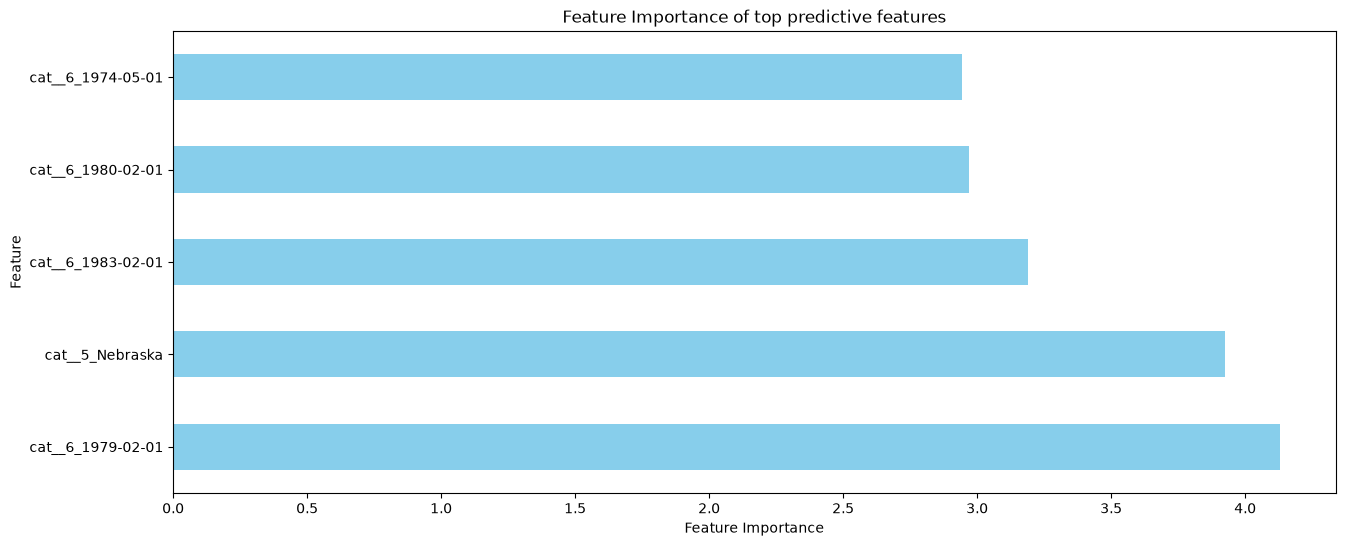

In [47]:
# Plot Top feature importances
fig, ax=plt.subplots(figsize=(15,6))
feat_imp.head().plot(kind="barh", ax=ax, color="skyblue",
                    ylabel="Feature", 
                    xlabel="Feature Importance",
                    title="Feature Importance of top predictive features");

- These results indicate that the model's predictions are being heavily influenced by a small number of one-hot encoded categorical features. The most important feature is cat__6_1979-02-01, followed by cat__5_Nebraska, with the remaining top features also corresponding to specific encoded categories. 
- Notably, four of the five most important features represent individual date values, while one represents a specific state. This suggests that the model may be capturing strong patterns associated with particular dates and locations in the training data. However, the prominence of individual dates as top predictors raises a concern that the model could be learning highly specific patterns that may not generalize well to new data, especially if those dates correspond to unique observations or small groups of records.

To improve the model, it would be worthwhile to revisit the original date feature and extract more meaningful components such as year, month, age, or tenure rather than one-hot encoding every unique date. This can help the model learn broader trends instead of memorizing specific dates. Similarly, it may be useful to examine the Nebraska category to understand why it is so influential and whether it reflects a genuine relationship with the target variable or an artifact of the dataset. Feature engineering and reducing high-cardinality categorical variables can often improve both model interpretability and generalization performance.

In [50]:
feat_imp.tail(10)

cat__6_1991-05-01    0.440827
cat__6_1980-09-01    0.437934
cat__5_Wyoming       0.405163
cat__6_1982-11-01    0.403989
cat__6_1986-03-01    0.398847
cat__6_2008-04-01    0.364879
cat__6_1984-07-01    0.361752
cat__6_1980-08-01    0.355238
cat__6_1984-05-01    0.267763
cat__6_1991-06-01    0.264987
dtype: float64

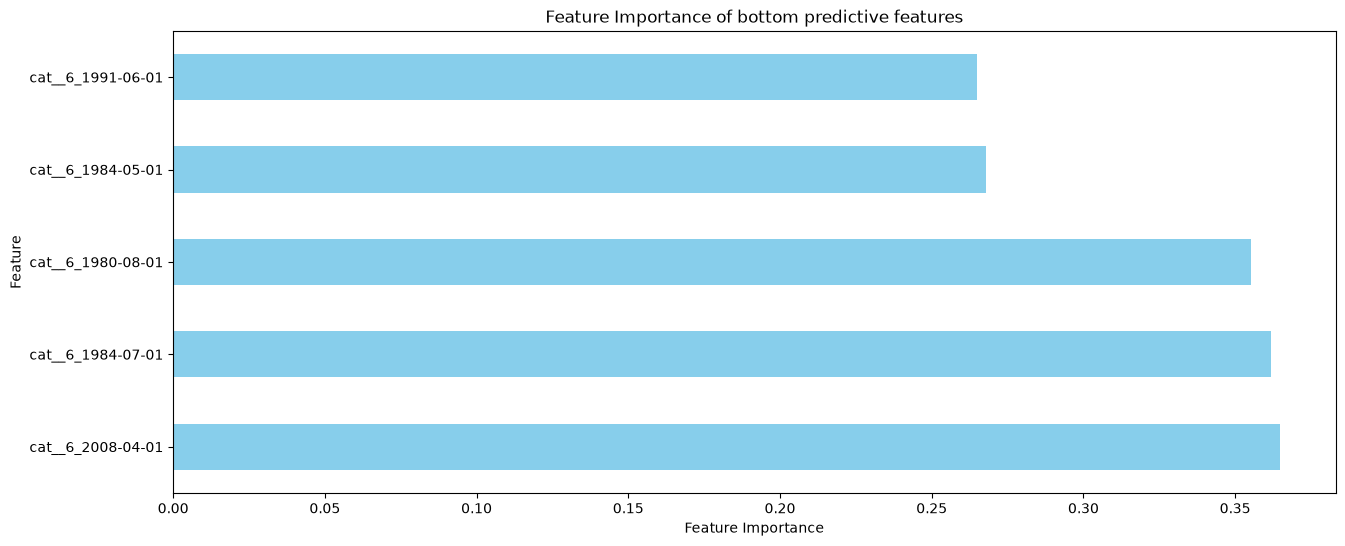

In [49]:
# Plot Bottom feature importances
fig, ax=plt.subplots(figsize=(15,6))
feat_imp.tail().plot(kind="barh", ax=ax, color="skyblue",
                    ylabel="Feature", 
                    xlabel="Feature Importance",
                    title="Feature Importance of bottom predictive features");

- The least important predictors have substantially smaller importance values, ranging from approximately 0.26 to 0.44, indicating that they contribute relatively little to the model's predictions. 
- Similar to the most important features, most of these variables correspond to specific one-hot encoded date values, such as 1991-05-01, 1982-11-01, and 1986-03-01, while Wyoming is the only geographic category appearing among the bottom predictors. Their low importance suggests that the model finds little predictive value in distinguishing observations belonging to these particular categories, either because they have weak relationships with the target variable or because they occur infrequently in the dataset.

The fact that many individual date categories appear among both the most and least important predictors reinforces the likelihood that the original date variable has high cardinality and may not be optimally represented through one-hot encoding. Rather than treating each date as a separate category, transforming the date into more informative features such as year, month, age, or duration could help the model capture meaningful temporal patterns while reducing noise. Additionally, features with consistently low importance may be candidates for removal or consolidation during future feature selection exercises, potentially simplifying the model without materially affecting its predictive performance.